In [ ]:
# =============================================================================
# SETUP
# =============================================================================
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -q timm transformers peft scikit-learn tqdm matplotlib

In [ ]:
!pip install --upgrade torchao

In [ ]:
import os, json, random, time, gc, warnings
warnings.filterwarnings("ignore")

In [ ]:
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, re, gc

import cv2
from PIL import Image
import torch

!pip install -q grad-cam
from pytorch_grad_cam import GradCAM, HiResCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import timm
from transformers import CLIPModel
from peft import LoraConfig, inject_adapter_in_model

from sklearn.metrics import roc_auc_score
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

In [ ]:
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
gc.collect(); torch.cuda.empty_cache()

Using device: cuda


In [ ]:
# =============================================================================
# EXTRACT DATASETS
# =============================================================================
if not os.path.exists("/content/ODIR"):
    !unzip -o -q "/content/drive/MyDrive/Retinal_project/ODIR.zip" -d "/content/ODIR"
if not os.path.exists("/content/APTOS"):
    !unzip -o -q "/content/drive/MyDrive/Retinal_project/aptos.zip" -d "/content/APTOS"
if not os.path.exists("/content/IDRiD"):
    !unzip -o -q "/content/drive/MyDrive/Retinal_project/Idrid.zip" -d "/content/IDRiD"
print("Datasets ready")

Datasets ready


In [ ]:
#08180# =============================================================================
# PATHS
# =============================================================================
BASE_DIR = "/content/drive/MyDrive/Retinal_project"
SAVE_DIR = os.path.join(BASE_DIR, "checkpoints")
RESULT_DIR = os.path.join(BASE_DIR, "results")

PLOT_DIR = os.path.join(BASE_DIR, "plots_complete")
os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

ODIR_CSV  = "/content/ODIR/odir/full_df.csv"
ODIR_IMGS = "/content/ODIR/odir/ODIR-5K/ODIR-5K/Training Images"
APTOS_TEST_CSV  = "/content/APTOS/test.csv"
APTOS_TEST_IMGS = "/content/APTOS/test_images/test_images"

IDRID_BASE   = "/content/IDRiD/IDRiD_dataset"
IDRID_GRADE  = os.path.join(IDRID_BASE, "B. Disease Grading")
IDRID_LABELS = os.path.join(IDRID_GRADE, "2. Groundtruths",
                             "a. IDRiD_Disease Grading_Training Labels.csv")

In [ ]:
import pandas as pd
odir_full_raw = pd.read_csv(ODIR_CSV)
print("All columns:", list(odir_full_raw.columns))
print("\nFirst 3 rows:")
print(odir_full_raw.head(3))

All columns: ['ID', 'Patient Age', 'Patient Sex', 'Left-Fundus', 'Right-Fundus', 'Left-Diagnostic Keywords', 'Right-Diagnostic Keywords', 'N', 'D', 'G', 'C', 'A', 'H', 'M', 'O', 'filepath', 'labels', 'target', 'filename']

First 3 rows:
   ID  Patient Age Patient Sex Left-Fundus Right-Fundus  \
0   0           69      Female  0_left.jpg  0_right.jpg   
1   1           57        Male  1_left.jpg  1_right.jpg   
2   2           42        Male  2_left.jpg  2_right.jpg   

                            Left-Diagnostic Keywords  \
0                                           cataract   
1                                      normal fundus   
2  laser spot，moderate non proliferative retinopathy   

                Right-Diagnostic Keywords  N  D  G  C  A  H  M  O  \
0                           normal fundus  0  0  0  1  0  0  0  0   
1                           normal fundus  1  0  0  0  0  0  0  0   
2  moderate non proliferative retinopathy  0  1  0  0  0  0  0  1   

                        

In [ ]:
all_keywords = pd.concat([
    odir_full_raw["Left-Diagnostic Keywords"],
    odir_full_raw["Right-Diagnostic Keywords"]
]).dropna().str.lower()

dr_related = all_keywords[all_keywords.str.contains("retinopathy", na=False)]
print("Unique DR-related keyword phrases:")
print(dr_related.value_counts())

Unique DR-related keyword phrases:
moderate non proliferative retinopathy                             1462
mild nonproliferative retinopathy                                   900
severe nonproliferative retinopathy                                 286
hypertensive retinopathy                                            207
moderate non proliferative retinopathy，hypertensive retinopathy      62
                                                                   ... 
laser spot，moderate non proliferative retinopathy，white vessel        1
lens dust，mild nonproliferative retinopathy                           1
white vessel，mild nonproliferative retinopathy                        1
optic disk photographically invisible，diabetic retinopathy            1
central serous chorioretinopathy                                      1
Name: count, Length: 137, dtype: int64


In [ ]:
# =============================================================================
# HYPERPARAMETERS
# =============================================================================
IMG_SIZE     = 224
BATCH_SIZE   = 32
EPOCHS       = 10
PATIENCE     = 4
LR_FULL      = 1e-5
LR_LINEAR    = 1e-3
LR_LORA_BB   = 5e-5
LR_LORA_HEAD = 2e-4
WEIGHT_DECAY = 0.01
GRAD_CLIP    = 1.0
N_BOOTSTRAP  = 1000

In [ ]:
# =============================================================================
# TRANSFORMS
# =============================================================================
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD  = [0.229, 0.224, 0.225]
CLIP_MEAN = [0.48145466, 0.4578275, 0.40821073]
CLIP_STD  = [0.26862954, 0.26130258, 0.27577711]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
])
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
])
clip_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(CLIP_MEAN, CLIP_STD),
])
clip_eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(CLIP_MEAN, CLIP_STD),
])

In [ ]:
# =============================================================================
# DATA LOADING
# =============================================================================
def prepare_aptos_df(csv_path, img_dir):
    df = pd.read_csv(csv_path)
    result = []
    for _, row in df.iterrows():
        fname = str(row["id_code"])
        if not fname.endswith(".png"):
            fname += ".png"
        img_path = os.path.join(img_dir, fname)
        if not os.path.exists(img_path):
            continue
        label = 1 if int(row["diagnosis"]) >= 1 else 0
        result.append({"image_path": img_path, "label": label})
    return pd.DataFrame(result)

def prepare_odir_binary(csv_path, img_dir):
    df = pd.read_csv(csv_path)
    result = []
    for _, row in df.iterrows():
        for fundus_col in ["Left-Fundus", "Right-Fundus"]:
            fname    = str(row.get(fundus_col, ""))
            img_path = os.path.join(img_dir, fname)
            if not os.path.exists(img_path):
                continue
            label = 1 if int(row.get("D", 0)) == 1 else 0
            result.append({
                "image_path": img_path,
                "label":      label,
                "patient_id": int(row["ID"])
            })
    return pd.DataFrame(result)

print("Loading data...")
odir_all  = prepare_odir_binary(ODIR_CSV, ODIR_IMGS)
patients  = odir_all["patient_id"].unique()
tr_ids, temp  = train_test_split(patients, test_size=0.3, random_state=SEED)
v_ids, te_ids = train_test_split(temp,     test_size=0.5, random_state=SEED)

odir_train = odir_all[odir_all["patient_id"].isin(tr_ids)].reset_index(drop=True)
odir_val   = odir_all[odir_all["patient_id"].isin(v_ids)].reset_index(drop=True)
odir_test  = odir_all[odir_all["patient_id"].isin(te_ids)].reset_index(drop=True)

assert len(set(odir_train["patient_id"]) & set(odir_val["patient_id"]))  == 0
assert len(set(odir_train["patient_id"]) & set(odir_test["patient_id"])) == 0
assert len(set(odir_val["patient_id"])   & set(odir_test["patient_id"])) == 0
print(f"ODIR — Train:{len(odir_train)} Val:{len(odir_val)} Test:{len(odir_test)}")

aptos_test = prepare_aptos_df(APTOS_TEST_CSV, APTOS_TEST_IMGS)
print(f"APTOS Test: {len(aptos_test)}")

Loading data...
ODIR — Train:8946 Val:1918 Test:1920
APTOS Test: 366


In [ ]:
# =============================================================================
# DATASET CLASS
# =============================================================================
class BinaryDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        label = torch.tensor(row["label"], dtype=torch.float32)
        return self.transform(image), label

In [ ]:
# =============================================================================
# MODEL BUILDERS — DINOv2
# =============================================================================
def build_dinov2_full():
    m = timm.create_model("vit_small_patch14_dinov2", pretrained=True,
                           num_classes=1, dynamic_img_size=True)
    for p in m.parameters(): p.requires_grad = True
    return m.to(device)

def build_dinov2_linear():
    m = timm.create_model("vit_small_patch14_dinov2", pretrained=True,
                           num_classes=1, dynamic_img_size=True)
    for p in m.parameters(): p.requires_grad = False
    for p in m.head.parameters(): p.requires_grad = True
    return m.to(device)

def build_dinov2_lora():
    m = timm.create_model("vit_small_patch14_dinov2", pretrained=True,
                           num_classes=1, dynamic_img_size=True)
    for p in m.parameters(): p.requires_grad = False
    cfg = LoraConfig(r=8, lora_alpha=16, lora_dropout=0.05,
                     target_modules=["attn.qkv","attn.proj"], bias="none")
    m = inject_adapter_in_model(cfg, m)
    for p in m.head.parameters(): p.requires_grad = True
    return m.to(device)

In [ ]:
# =============================================================================
# MODEL BUILDERS — CLIP
# =============================================================================
class CLIPBinaryClassifier(nn.Module):
    def __init__(self, mode="linear"):
        super().__init__()
        clip_base         = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
        self.vision_model = clip_base.vision_model
        hidden_size       = clip_base.config.vision_config.hidden_size
        if mode == "full":
            for p in self.vision_model.parameters(): p.requires_grad = True
        elif mode == "linear":
            for p in self.vision_model.parameters(): p.requires_grad = False
        elif mode == "lora":
            for p in self.vision_model.parameters(): p.requires_grad = False
            cfg = LoraConfig(r=8, lora_alpha=16, lora_dropout=0.05,
                             target_modules=["q_proj","v_proj"], bias="none")
            self.vision_model = inject_adapter_in_model(cfg, self.vision_model)
        self.classifier = nn.Linear(hidden_size, 1)
    def forward(self, pixel_values):
        out = self.vision_model(pixel_values=pixel_values)
        return self.classifier(out.pooler_output)

def build_clip_full():   return CLIPBinaryClassifier("full").to(device)
def build_clip_linear(): return CLIPBinaryClassifier("linear").to(device)
def build_clip_lora():   return CLIPBinaryClassifier("lora").to(device)

In [ ]:
# =============================================================================
# MODEL BUILDERS — Plain ViT (supervised ImageNet pretraining)
# =============================================================================
def build_vit_full():
    m = timm.create_model("vit_small_patch16_224", pretrained=True, num_classes=1)
    for p in m.parameters(): p.requires_grad = True
    return m.to(device)

def build_vit_linear():
    m = timm.create_model("vit_small_patch16_224", pretrained=True, num_classes=1)
    for p in m.parameters(): p.requires_grad = False
    for p in m.head.parameters(): p.requires_grad = True
    return m.to(device)

def build_vit_lora():
    m = timm.create_model("vit_small_patch16_224", pretrained=True, num_classes=1)
    for p in m.parameters(): p.requires_grad = False
    cfg = LoraConfig(r=8, lora_alpha=16, lora_dropout=0.05,
                     target_modules=["attn.qkv","attn.proj"], bias="none")
    m = inject_adapter_in_model(cfg, m)
    for p in m.head.parameters(): p.requires_grad = True
    return m.to(device)

In [ ]:
# =============================================================================
# ALL 9 MODEL CONFIGS
# =============================================================================
ALL_CONFIGS = [
    {"name": "DINOv2-Full",   "builder": build_dinov2_full,
     "is_clip": False, "lr_head": LR_FULL,     "lr_bb": LR_FULL},

    {"name": "DINOv2-Linear", "builder": build_dinov2_linear,
     "is_clip": False, "lr_head": LR_LINEAR,   "lr_bb": None},

    {"name": "DINOv2-LoRA",   "builder": build_dinov2_lora,
     "is_clip": False, "lr_head": LR_LORA_HEAD, "lr_bb": LR_LORA_BB},

    {"name": "CLIP-Full",     "builder": build_clip_full,
     "is_clip": True,  "lr_head": LR_FULL,     "lr_bb": LR_FULL},

    {"name": "CLIP-Linear",   "builder": build_clip_linear,
     "is_clip": True,  "lr_head": LR_LINEAR,   "lr_bb": None},

    {"name": "CLIP-LoRA",     "builder": build_clip_lora,
     "is_clip": True,  "lr_head": LR_LORA_HEAD, "lr_bb": LR_LORA_BB},

    {"name": "ViT-Full",      "builder": build_vit_full,
     "is_clip": False, "lr_head": LR_FULL,     "lr_bb": LR_FULL},

    {"name": "ViT-Linear",    "builder": build_vit_linear,
     "is_clip": False, "lr_head": LR_LINEAR,   "lr_bb": None},

    {"name": "ViT-LoRA",      "builder": build_vit_lora,
     "is_clip": False, "lr_head": LR_LORA_HEAD, "lr_bb": LR_LORA_BB},
]

print(f"\nTotal models configured: {len(ALL_CONFIGS)}")
for c in ALL_CONFIGS:
    print(f"  - {c['name']}")


Total models configured: 9
  - DINOv2-Full
  - DINOv2-Linear
  - DINOv2-LoRA
  - CLIP-Full
  - CLIP-Linear
  - CLIP-LoRA
  - ViT-Full
  - ViT-Linear
  - ViT-LoRA


In [ ]:
old_ckpt = os.path.join(SAVE_DIR, "ckpt_clip_lora.pth")
if os.path.exists(old_ckpt):
    state = torch.load(old_ckpt, map_location="cpu")
    needs_fix = any(k.startswith("vm.") or k.startswith("cls.") for k in state.keys())
    if needs_fix:
        new_state = {}
        for k, v in state.items():
            new_k = k
            if k.startswith("vm."):
                new_k = "vision_model." + k[len("vm."):]
            elif k.startswith("cls."):
                new_k = "classifier." + k[len("cls."):]
            new_state[new_k] = v
        torch.save(new_state, old_ckpt)
        print("CLIP-LoRA checkpoint keys fixed and re-saved.")

        # quick sanity check, then free memory immediately
        _m = build_clip_lora()
        missing, unexpected = _m.load_state_dict(new_state, strict=False)
        print("  Missing:", missing)
        print("  Unexpected:", unexpected)
        del _m
        gc.collect(); torch.cuda.empty_cache()
    else:
        print("CLIP-LoRA checkpoint already uses correct key names — no fix needed.")

CLIP-LoRA checkpoint already uses correct key names — no fix needed.


In [ ]:
# =============================================================================
# TRAINING FUNCTIONS
# =============================================================================
torch.backends.cudnn.benchmark = True
def get_optimizer(model, lr_head, lr_bb=None):
    head_p = [p for n,p in model.named_parameters()
               if p.requires_grad and ("head" in n or "classifier" in n)]
    bb_p   = [p for n,p in model.named_parameters()
               if p.requires_grad and "head" not in n and "classifier" not in n]
    groups = [{"params": head_p, "lr": lr_head, "weight_decay": WEIGHT_DECAY}]
    if bb_p and lr_bb:
        groups.append({"params": bb_p, "lr": lr_bb, "weight_decay": WEIGHT_DECAY})
    elif bb_p:
        groups.append({"params": bb_p, "lr": lr_head, "weight_decay": WEIGHT_DECAY})
    return torch.optim.AdamW(groups)

def train_one_epoch(model, loader, criterion, optimizer, epoch, total):
    model.train()
    running = 0.0
    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{total}", leave=True)
    for bidx, (imgs, labels) in enumerate(pbar):
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True).unsqueeze(1)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        running += loss.item()
        pbar.set_postfix(loss=f"{running/(bidx+1):.4f}")
    return running / len(loader)

def get_probs(model, df, transform):
    model.eval()

    loader = DataLoader(
        BinaryDataset(df, transform),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=4,
        pin_memory=True,
        persistent_workers=True
    )

    yt, yp = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device, non_blocking=True)

            probs = torch.sigmoid(
                model(imgs)
            ).squeeze(1)

            yt.extend(labels.numpy())
            yp.extend(probs.cpu().numpy())

    return np.array(yt), np.array(yp)

def safe_auroc(yt, yp):
    return roc_auc_score(yt, yp) if len(np.unique(yt)) > 1 else 0.0

def bootstrap_auroc(yt, yp, n=N_BOOTSTRAP):
    aurocs = []
    for _ in range(n):
        idx = np.random.choice(len(yt), len(yt), replace=True)
        if len(np.unique(yt[idx])) < 2: continue
        aurocs.append(roc_auc_score(yt[idx], yp[idx]))
    a = np.array(aurocs)
    return np.mean(a), np.percentile(a, 2.5), np.percentile(a, 97.5)

def calibrate(val_yt, val_yp, test_yp):
    ir = IsotonicRegression(out_of_bounds="clip")
    ir.fit(val_yp, val_yt)
    return ir.predict(test_yp)

def fmt(m, lo, hi): return f"{m:.3f} ({lo:.3f}, {hi:.3f})"

def train_and_save(cfg, ckpt_path):
    t_tr = clip_train_transform if cfg["is_clip"] else train_transform
    t_ev = clip_eval_transform  if cfg["is_clip"] else eval_transform

    model = cfg["builder"]()
    n_pos = odir_train["label"].sum()
    n_neg = len(odir_train) - n_pos
    pos_w = torch.tensor([n_neg/(n_pos+1e-6)], dtype=torch.float32).to(device)
    crit  = nn.BCEWithLogitsLoss(pos_weight=pos_w)

    train_loader = DataLoader(
    BinaryDataset(odir_train, t_tr),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

    opt   = get_optimizer(model, cfg["lr_head"], cfg.get("lr_bb"))
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS, eta_min=1e-6)

    best_auroc = 0.0; patience_ctr = 0
    for epoch in range(EPOCHS):
        t    = time.time()
        loss = train_one_epoch(model, train_loader, crit, opt, epoch, EPOCHS)
        vyt, vyp  = get_probs(model, odir_val, t_ev)
        val_auroc = safe_auroc(vyt, vyp)
        print(f"  Ep {epoch+1}/{EPOCHS} | Loss={loss:.4f} | "
              f"Val AUROC={val_auroc:.4f} | {time.time()-t:.0f}s")
        if val_auroc > best_auroc:
            best_auroc = val_auroc; patience_ctr = 0
            torch.save(model.state_dict(), ckpt_path)
            print(f"    -> Best saved ({val_auroc:.4f})")
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(f"  Early stopping at epoch {epoch+1}")
                break
        sched.step()
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    return model

In [ ]:
import torch
import torch.nn as nn
import timm
from peft import LoraConfig, inject_adapter_in_model
from transformers import CLIPModel

results = {}

# ── DINOv2-Full ──────────────────────────────────────────
m = timm.create_model("vit_small_patch14_dinov2",
                       pretrained=False, num_classes=1, dynamic_img_size=True)
for p in m.parameters(): p.requires_grad = True
tr = sum(p.numel() for p in m.parameters() if p.requires_grad)
tt = sum(p.numel() for p in m.parameters())
results["DINOv2-Full"] = (tr, tt)

# ── DINOv2-Linear ────────────────────────────────────────
m = timm.create_model("vit_small_patch14_dinov2",
                       pretrained=False, num_classes=1, dynamic_img_size=True)
for p in m.parameters(): p.requires_grad = False
for p in m.head.parameters(): p.requires_grad = True
tr = sum(p.numel() for p in m.parameters() if p.requires_grad)
tt = sum(p.numel() for p in m.parameters())
results["DINOv2-Linear"] = (tr, tt)

# ── DINOv2-LoRA ──────────────────────────────────────────
m = timm.create_model("vit_small_patch14_dinov2",
                       pretrained=False, num_classes=1, dynamic_img_size=True)
for p in m.parameters(): p.requires_grad = False
cfg = LoraConfig(r=8, lora_alpha=16, lora_dropout=0.05,
                  target_modules=["attn.qkv","attn.proj"], bias="none")
m = inject_adapter_in_model(cfg, m)
for p in m.head.parameters(): p.requires_grad = True
tr = sum(p.numel() for p in m.parameters() if p.requires_grad)
tt = sum(p.numel() for p in m.parameters())
results["DINOv2-LoRA"] = (tr, tt)

# ── CLIP-Full ────────────────────────────────────────────
clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
vm   = clip.vision_model
for p in vm.parameters(): p.requires_grad = True
hsz  = clip.config.vision_config.hidden_size
cls  = nn.Linear(hsz, 1)
tr   = sum(p.numel() for p in vm.parameters() if p.requires_grad) + \
       sum(p.numel() for p in cls.parameters())
tt   = sum(p.numel() for p in vm.parameters()) + \
       sum(p.numel() for p in cls.parameters())
results["CLIP-Full"] = (tr, tt)

# ── CLIP-Linear ──────────────────────────────────────────
clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
vm   = clip.vision_model
for p in vm.parameters(): p.requires_grad = False
cls  = nn.Linear(hsz, 1)
tr   = sum(p.numel() for p in cls.parameters())
tt   = sum(p.numel() for p in vm.parameters()) + \
       sum(p.numel() for p in cls.parameters())
results["CLIP-Linear"] = (tr, tt)

# ── CLIP-LoRA ────────────────────────────────────────────
clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
vm   = clip.vision_model
for p in vm.parameters(): p.requires_grad = False
cfg2 = LoraConfig(r=8, lora_alpha=16, lora_dropout=0.05,
                   target_modules=["q_proj","v_proj"], bias="none")
vm   = inject_adapter_in_model(cfg2, vm)
cls  = nn.Linear(hsz, 1)
tr   = sum(p.numel() for p in vm.parameters() if p.requires_grad) + \
       sum(p.numel() for p in cls.parameters())
tt   = sum(p.numel() for p in vm.parameters()) + \
       sum(p.numel() for p in cls.parameters())
results["CLIP-LoRA"] = (tr, tt)

# ── ViT-Full ─────────────────────────────────────────────
m = timm.create_model("vit_small_patch16_224",
                       pretrained=False, num_classes=1)
for p in m.parameters(): p.requires_grad = True
tr = sum(p.numel() for p in m.parameters() if p.requires_grad)
tt = sum(p.numel() for p in m.parameters())
results["ViT-Full"] = (tr, tt)

# ── ViT-Linear ───────────────────────────────────────────
m = timm.create_model("vit_small_patch16_224",
                       pretrained=False, num_classes=1)
for p in m.parameters(): p.requires_grad = False
for p in m.head.parameters(): p.requires_grad = True
tr = sum(p.numel() for p in m.parameters() if p.requires_grad)
tt = sum(p.numel() for p in m.parameters())
results["ViT-Linear"] = (tr, tt)

# ── ViT-LoRA ─────────────────────────────────────────────
m = timm.create_model("vit_small_patch16_224",
                       pretrained=False, num_classes=1)
for p in m.parameters(): p.requires_grad = False
cfg3 = LoraConfig(r=8, lora_alpha=16, lora_dropout=0.05,
                   target_modules=["attn.qkv","attn.proj"], bias="none")
m = inject_adapter_in_model(cfg3, m)
for p in m.head.parameters(): p.requires_grad = True
tr = sum(p.numel() for p in m.parameters() if p.requires_grad)
tt = sum(p.numel() for p in m.parameters())
results["ViT-LoRA"] = (tr, tt)

# ── Print Table ──────────────────────────────────────────
print(f"\n{'Model':<18} {'Trainable':>12} {'Total':>12} {'%':>8}")
print("-" * 55)
for name, (tr, tt) in results.items():
    print(f"{name:<18} {tr:>12,} {tt:>12,} {100*tr/tt:>7.2f}%")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]


Model                 Trainable        Total        %
-------------------------------------------------------
DINOv2-Full          22,056,577   22,056,577  100.00%
DINOv2-Linear               385   22,056,577    0.00%
DINOv2-LoRA             221,569   22,277,761    0.99%
CLIP-Full            87,456,769   87,456,769  100.00%
CLIP-Linear                 769   87,456,769    0.00%
CLIP-LoRA               295,681   87,751,681    0.34%
ViT-Full             21,666,049   21,666,049  100.00%
ViT-Linear                  385   21,666,049    0.00%
ViT-LoRA                221,569   21,887,233    1.01%


In [ ]:
# =============================================================================
# MAIN LOOP — SKIP ALREADY-TRAINED, TRAIN THE REST (should be only ViT-* here)
# =============================================================================
print("\n" + "="*70)
print(f"PROCESSING ALL {len(ALL_CONFIGS)} MODELS")
print("="*70)

all_results = {}

for cfg in ALL_CONFIGS:
    ckpt_path = os.path.join(SAVE_DIR,
                              f"ckpt_{cfg['name'].lower().replace('-','_')}.pth")
    t_ev = clip_eval_transform if cfg["is_clip"] else eval_transform

    print(f"\n{'='*50}")
    print(f"Model: {cfg['name']}")

    if os.path.exists(ckpt_path):
        print("  [SKIP] Loading existing checkpoint...")
        model = cfg["builder"]()
        state_dict = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(state_dict)
        model = model.to(device)
    else:
        print("  [TRAIN] Starting training...")
        model = train_and_save(cfg, ckpt_path)

    model.eval()
    val_yt,  val_yp  = get_probs(model, odir_val,   t_ev)
    test_yt, test_yp = get_probs(model, odir_test,  t_ev)
    ext_yt,  ext_yp  = get_probs(model, aptos_test, t_ev)

    print(f"  Computing bootstrap CI ({N_BOOTSTRAP} iterations)...")
    int_m, int_lo, int_hi = bootstrap_auroc(test_yt, test_yp)
    ext_m, ext_lo, ext_hi = bootstrap_auroc(ext_yt,  ext_yp)

    cal_test = calibrate(val_yt, val_yp, test_yp)
    cal_ext  = calibrate(val_yt, val_yp, ext_yp)

    all_results[cfg["name"]] = {
        "int_m": int_m, "int_lo": int_lo, "int_hi": int_hi,
        "ext_m": ext_m, "ext_lo": ext_lo, "ext_hi": ext_hi,
        "cal_internal": safe_auroc(test_yt, cal_test),
        "cal_external": safe_auroc(ext_yt,  cal_ext),
        "test_yt": test_yt, "test_yp": test_yp,
        "ext_yt":  ext_yt,  "ext_yp":  ext_yp,
        "val_yt":  val_yt,  "val_yp":  val_yp,
    }

    print(f"  Internal: {fmt(int_m, int_lo, int_hi)}")
    print(f"  External: {fmt(ext_m, ext_lo, ext_hi)}")
    print(f"  Cal Int: {safe_auroc(test_yt, cal_test):.3f} | "
          f"Cal Ext: {safe_auroc(ext_yt, cal_ext):.3f}")

    del model
    gc.collect(); torch.cuda.empty_cache()


PROCESSING ALL 9 MODELS

Model: DINOv2-Full
  [SKIP] Loading existing checkpoint...
  Computing bootstrap CI (1000 iterations)...
  Internal: 0.756 (0.731, 0.778)
  External: 0.920 (0.886, 0.952)
  Cal Int: 0.753 | Cal Ext: 0.916

Model: DINOv2-Linear
  [SKIP] Loading existing checkpoint...
  Computing bootstrap CI (1000 iterations)...
  Internal: 0.703 (0.679, 0.727)
  External: 0.843 (0.801, 0.884)
  Cal Int: 0.700 | Cal Ext: 0.839

Model: DINOv2-LoRA
  [SKIP] Loading existing checkpoint...
  Computing bootstrap CI (1000 iterations)...
  Internal: 0.758 (0.733, 0.782)
  External: 0.907 (0.869, 0.940)
  Cal Int: 0.753 | Cal Ext: 0.908

Model: CLIP-Full
  [SKIP] Loading existing checkpoint...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

  Computing bootstrap CI (1000 iterations)...
  Internal: 0.701 (0.676, 0.726)
  External: 0.756 (0.697, 0.809)
  Cal Int: 0.695 | Cal Ext: 0.748

Model: CLIP-Linear
  [SKIP] Loading existing checkpoint...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

  Computing bootstrap CI (1000 iterations)...
  Internal: 0.686 (0.662, 0.709)
  External: 0.805 (0.758, 0.848)
  Cal Int: 0.684 | Cal Ext: 0.796

Model: CLIP-LoRA
  [SKIP] Loading existing checkpoint...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

  Computing bootstrap CI (1000 iterations)...
  Internal: 0.701 (0.676, 0.726)
  External: 0.811 (0.764, 0.856)
  Cal Int: 0.696 | Cal Ext: 0.806

Model: ViT-Full
  [SKIP] Loading existing checkpoint...
  Computing bootstrap CI (1000 iterations)...
  Internal: 0.740 (0.713, 0.763)
  External: 0.920 (0.890, 0.947)
  Cal Int: 0.738 | Cal Ext: 0.918

Model: ViT-Linear
  [SKIP] Loading existing checkpoint...
  Computing bootstrap CI (1000 iterations)...
  Internal: 0.692 (0.666, 0.718)
  External: 0.791 (0.741, 0.835)
  Cal Int: 0.688 | Cal Ext: 0.782

Model: ViT-LoRA
  [SKIP] Loading existing checkpoint...
  Computing bootstrap CI (1000 iterations)...
  Internal: 0.716 (0.690, 0.739)
  External: 0.732 (0.681, 0.778)
  Cal Int: 0.717 | Cal Ext: 0.727


In [ ]:
import os

for cfg in ALL_CONFIGS:
    ckpt = os.path.join(
        SAVE_DIR,
        f"ckpt_{cfg['name'].lower().replace('-','_')}.pth"
    )
    print(cfg["name"], "->", ckpt, os.path.exists(ckpt))

DINOv2-Full -> /content/drive/MyDrive/Retinal_project/checkpoints/ckpt_dinov2_full.pth True
DINOv2-Linear -> /content/drive/MyDrive/Retinal_project/checkpoints/ckpt_dinov2_linear.pth True
DINOv2-LoRA -> /content/drive/MyDrive/Retinal_project/checkpoints/ckpt_dinov2_lora.pth True
CLIP-Full -> /content/drive/MyDrive/Retinal_project/checkpoints/ckpt_clip_full.pth True
CLIP-Linear -> /content/drive/MyDrive/Retinal_project/checkpoints/ckpt_clip_linear.pth True
CLIP-LoRA -> /content/drive/MyDrive/Retinal_project/checkpoints/ckpt_clip_lora.pth True
ViT-Full -> /content/drive/MyDrive/Retinal_project/checkpoints/ckpt_vit_full.pth True
ViT-Linear -> /content/drive/MyDrive/Retinal_project/checkpoints/ckpt_vit_linear.pth True
ViT-LoRA -> /content/drive/MyDrive/Retinal_project/checkpoints/ckpt_vit_lora.pth True


In [ ]:
# =============================================================================
# RESULTS TABLE
# =============================================================================
print("\n\n" + "="*85)
print("FINAL TABLE — Train: ODIR | Internal: ODIR | External: APTOS")
print("="*85)
print(f"{'Model':<18} {'Internal AUROC (95% CI)':>32} {'External AUROC (95% CI)':>32}")
print("-"*85)
for name, r in all_results.items():
    print(f"{name:<18} {fmt(r['int_m'],r['int_lo'],r['int_hi']):>32} "
          f"{fmt(r['ext_m'],r['ext_lo'],r['ext_hi']):>32}")
print("="*85)

print("\nCALIBRATED RESULTS (Isotonic Regression):")
print(f"{'Model':<18} {'Cal Internal':>15} {'Cal External':>15}")
print("-"*50)
for name, r in all_results.items():
    print(f"{name:<18} {r['cal_internal']:>15.3f} {r['cal_external']:>15.3f}")

best_name = max(all_results, key=lambda k: all_results[k]["int_m"])
print(f"\nBest model: {best_name} "
      f"(Internal AUROC={all_results[best_name]['int_m']:.4f})")



FINAL TABLE — Train: ODIR | Internal: ODIR | External: APTOS
Model                       Internal AUROC (95% CI)          External AUROC (95% CI)
-------------------------------------------------------------------------------------
DINOv2-Full                    0.756 (0.731, 0.778)             0.920 (0.886, 0.952)
DINOv2-Linear                  0.703 (0.679, 0.727)             0.843 (0.801, 0.884)
DINOv2-LoRA                    0.758 (0.733, 0.782)             0.907 (0.869, 0.940)
CLIP-Full                      0.701 (0.676, 0.726)             0.756 (0.697, 0.809)
CLIP-Linear                    0.686 (0.662, 0.709)             0.805 (0.758, 0.848)
CLIP-LoRA                      0.701 (0.676, 0.726)             0.811 (0.764, 0.856)
ViT-Full                       0.740 (0.713, 0.763)             0.920 (0.890, 0.947)
ViT-Linear                     0.692 (0.666, 0.718)             0.791 (0.741, 0.835)
ViT-LoRA                       0.716 (0.690, 0.739)             0.732 (0.681, 0.778)



In [ ]:
# Check for TRUE proliferative retinopathy (PDR) phrases — without "non"
pdr_only = dr_related[dr_related.str.contains("proliferative retinopathy", na=False) &
                       ~dr_related.str.contains("nonproliferative") &
                       ~dr_related.str.contains("non proliferative") &
                       ~dr_related.str.contains("non-proliferative")]
print("True PDR (proliferative, non-NPDR) phrases found:")
print(pdr_only.value_counts())

# Also check total unique phrase count vs what we categorized
print(f"\nTotal DR-related keyword entries: {len(dr_related)}")
print(f"Total unique phrases: {dr_related.nunique()}")

True PDR (proliferative, non-NPDR) phrases found:
Series([], Name: count, dtype: int64)

Total DR-related keyword entries: 3686
Total unique phrases: 137


In [ ]:
import pandas as pd

odir_full_raw = pd.read_csv(ODIR_CSV)

def extract_dr_severity(keyword_text):
    if pd.isna(keyword_text):
        return None
    text = str(keyword_text).lower()

    # Normalize spacing variants first — this is the critical fix
    normalized = (text.replace("non-proliferative", "nonproliferative")
                       .replace("non proliferative", "nonproliferative"))

    # Check NPDR (non-proliferative) FIRST — avoids false-matching
    # "proliferative retinopathy" as a substring inside "nonproliferative retinopathy"
    if "nonproliferative retinopathy" in normalized:
        if "severe" in normalized:
            return 3
        elif "moderate" in normalized:
            return 2
        elif "mild" in normalized:
            return 1
        else:
            return None  # NPDR without severity qualifier — ambiguous, exclude
    elif "proliferative retinopathy" in normalized:
        return 4  # true PDR
    elif "normal fundus" in normalized:
        return 0
    return None

odir_full_raw["left_severity"]  = odir_full_raw["Left-Diagnostic Keywords"].apply(extract_dr_severity)
odir_full_raw["right_severity"] = odir_full_raw["Right-Diagnostic Keywords"].apply(extract_dr_severity)

odir_severity = pd.concat([
    odir_full_raw["left_severity"],
    odir_full_raw["right_severity"]
]).dropna()

DR_GRADE_NAMES = {0: "No DR", 1: "Mild", 2: "Moderate", 3: "Severe", 4: "Proliferative DR"}

def print_prevalence(name, series):
    print(f"\n{name}")
    print("-" * 30)
    total = len(series)
    counts = series.value_counts().sort_index()
    for grade in range(5):
        cnt = int(counts.get(grade, 0))
        pct = round(100 * cnt / total, 1) if total > 0 else 0
        print(f"{DR_GRADE_NAMES[grade]:<18} {pct}% ({cnt})")
    print(f"{'Total':<18} 100% ({total})")

print_prevalence("ODIR (fixed)", odir_severity)


ODIR (fixed)
------------------------------
No DR              63.6% (5675)
Mild               11.8% (1057)
Moderate           21.0% (1877)
Severe             3.5% (312)
Proliferative DR   0.0% (0)
Total              100% (8921)


In [ ]:
aptos_raw = pd.read_csv(APTOS_TEST_CSV)
aptos_severity = aptos_raw["diagnosis"].dropna()
print_prevalence("APTOS", aptos_severity)


APTOS
------------------------------
No DR              54.4% (199)
Mild               8.2% (30)
Moderate           23.8% (87)
Severe             4.6% (17)
Proliferative DR   9.0% (33)
Total              100% (366)


In [ ]:
# =============================================================================
# SAVE JSON SUMMARY
# =============================================================================

summary = {name: {
    "internal_auroc": round(r["int_m"], 4),
    "internal_ci":    [round(r["int_lo"],4), round(r["int_hi"],4)],
    "external_auroc": round(r["ext_m"], 4),
    "external_ci":    [round(r["ext_lo"],4), round(r["ext_hi"],4)],
    "cal_internal":   round(r["cal_internal"], 4),
    "cal_external":   round(r["cal_external"], 4),
} for name, r in all_results.items()}

summary["best_model"] = best_name


with open(os.path.join(RESULT_DIR, "final_results_9models.json"), "w") as f:
    json.dump(summary, f, indent=2)

print(f"\nResults saved: {os.path.join(RESULT_DIR, 'final_results_9models.json')}")


Results saved: /content/drive/MyDrive/Retinal_project/results/final_results_9models.json



Top 2 models by internal AUROC: ['DINOv2-LoRA', 'DINOv2-Full']


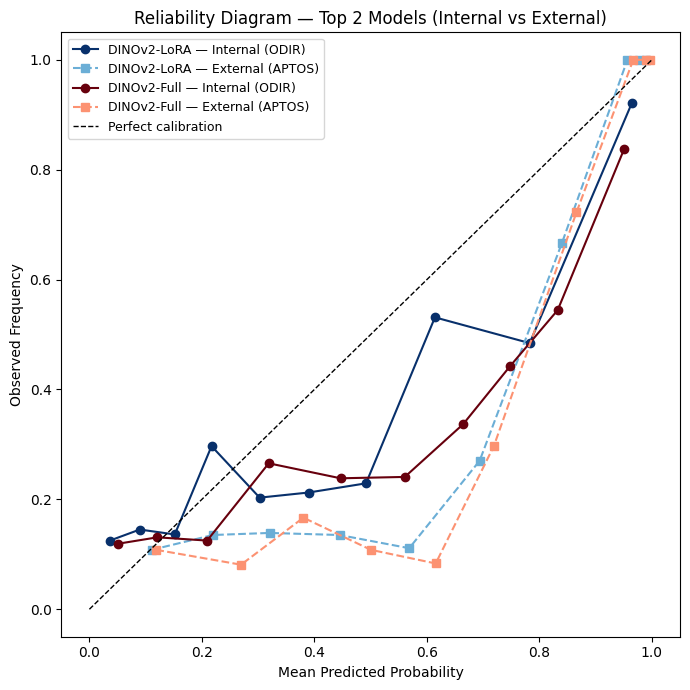

Saved: /content/drive/MyDrive/Retinal_project/plots_complete/reliability_diagram.png


In [ ]:
# =============================================================================
# RELIABILITY / CALIBRATION PLOT — Top 2 models, Internal + External (4 lines)
# =============================================================================
def plot_reliability(all_results, model_names, save_path):
    plt.figure(figsize=(7,7))
    colors = {
        model_names[0]: {"int": "#08306b", "ext": "#6baed6"},  # dark blue / light blue
        model_names[1]: {"int": "#67000d", "ext": "#fc9272"},  # dark red / light red
    }
    for name in model_names:
        r = all_results[name]
        frac_pos, mean_pred = calibration_curve(r["test_yt"], r["test_yp"], n_bins=10, strategy="quantile")
        plt.plot(mean_pred, frac_pos, marker="o", color=colors[name]["int"],
                  label=f"{name} — Internal (ODIR)")
        frac_pos_e, mean_pred_e = calibration_curve(r["ext_yt"], r["ext_yp"], n_bins=10, strategy="quantile")
        plt.plot(mean_pred_e, frac_pos_e, marker="s", linestyle="--", color=colors[name]["ext"],
                  label=f"{name} — External (APTOS)")
    plt.plot([0,1],[0,1],"k--",lw=1, label="Perfect calibration")
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Observed Frequency")
    plt.title("Reliability Diagram — Top 2 Models (Internal vs External)")
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved: {save_path}")

ranked = sorted(all_results.items(), key=lambda kv: -kv[1]["int_m"])
top2 = [ranked[0][0], ranked[1][0]]
print("\nTop 2 models by internal AUROC:", top2)
plot_reliability(all_results, top2, os.path.join(PLOT_DIR, "reliability_diagram.png"))

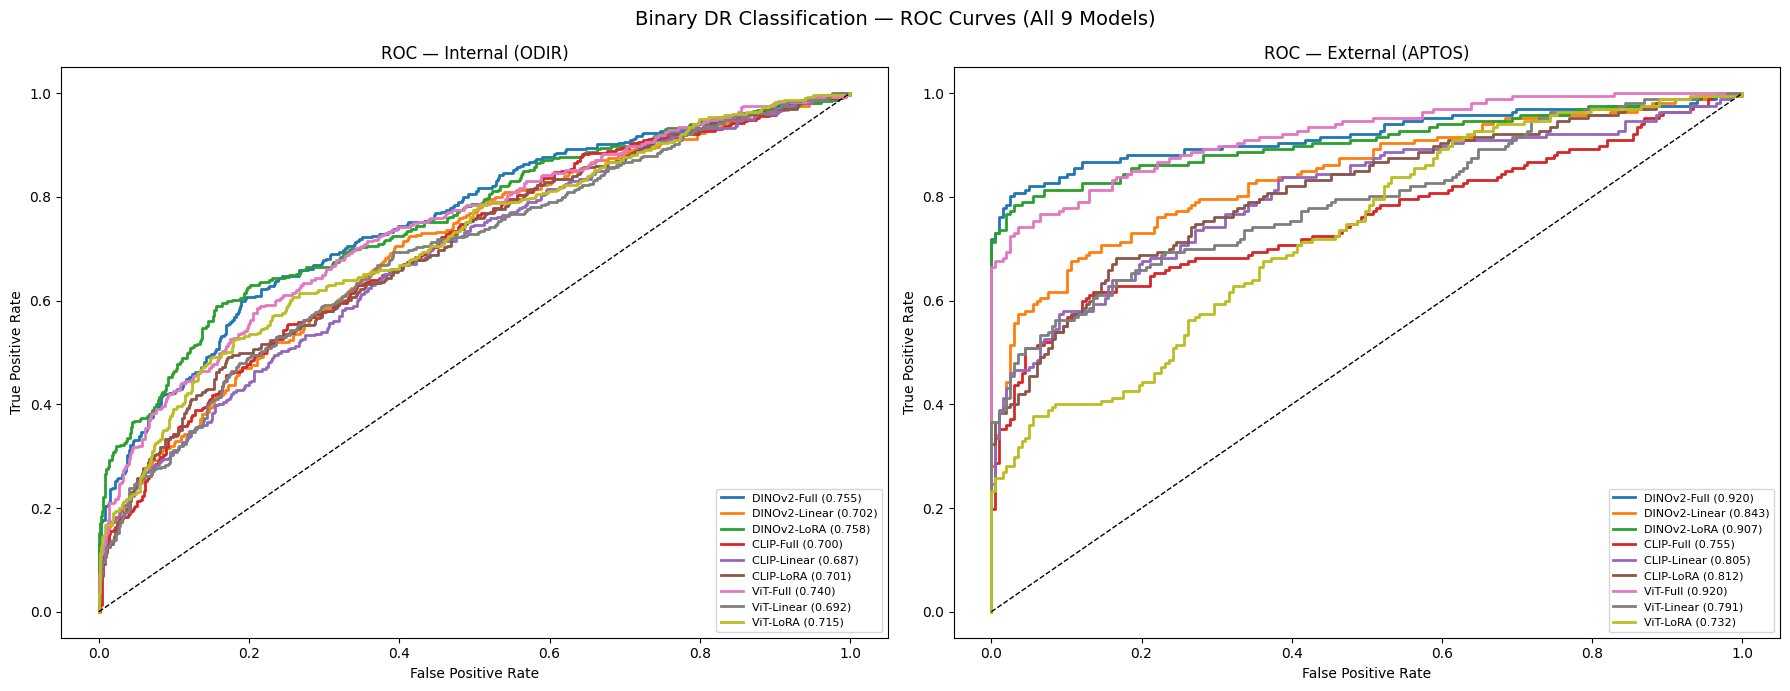

ROC curves saved: /content/drive/MyDrive/Retinal_project/plots_complete/roc_all_9models.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 9 distinct colors for 9 models
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
          "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22"]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for (name, r), col in zip(all_results.items(), colors):
    for ax, yt, yp in [
        (axes[0], r["test_yt"], r["test_yp"]),   # Internal (ODIR)
        (axes[1], r["ext_yt"],  r["ext_yp"])     # External (APTOS)
    ]:
        if len(np.unique(yt)) < 2:
            continue
        fpr, tpr, _ = roc_curve(yt, yp)
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=col, lw=2, label=f"{name} ({roc_auc:.3f})")

for ax, title in zip(axes, ["Internal (ODIR)", "External (APTOS)"]):
    ax.plot([0,1], [0,1], "k--", lw=1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"ROC — {title}")
    ax.legend(fontsize=8, loc="lower right")

plt.suptitle("Binary DR Classification — ROC Curves (All 9 Models)", fontsize=14)
plt.tight_layout()

roc_path = os.path.join(PLOT_DIR, "roc_all_9models.png")
plt.savefig(roc_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"ROC curves saved: {roc_path}")

In [ ]:
# =============================================================================
# IDRiD PATHS
# =============================================================================
if not os.path.exists("/content/IDRiD"):
    !unzip -o -q "/content/drive/MyDrive/Retinal_project/Idrid.zip" -d "/content/IDRiD"

IDRID_BASE   = "/content/IDRiD/IDRiD_dataset"
IDRID_SEG    = os.path.join(IDRID_BASE, "A. Segmentation")
IMG_DIR      = os.path.join(IDRID_SEG, "1. Original Images", "a. Training Set")
MASK_ROOT    = os.path.join(IDRID_SEG, "2. All Segmentation Groundtruths", "a. Training Set")
LABELS_CSV   = os.path.join(IDRID_BASE, "B. Disease Grading",
                             "2. Groundtruths", "a. IDRiD_Disease Grading_Training Labels.csv")

In [ ]:
# =============================================================================
# BEST MODEL — confirmed DINOv2-LoRA from the 9-model comparison
# =============================================================================
BEST_NAME = "DINOv2-LoRA"
CKPT_PATH = os.path.join(SAVE_DIR, f"ckpt_{BEST_NAME.lower().replace('-','_')}.pth")

model = build_dinov2_lora()
model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
model.eval()
for blk in model.blocks:
    if hasattr(blk.attn, "fused_attn"):
        blk.attn.fused_attn = False
print(f"Loaded {BEST_NAME} checkpoint successfully")

def get_prediction(model, inp):
    with torch.no_grad():
        logit = model(inp)
        prob = torch.sigmoid(logit).item()
    return prob, ("DR Positive" if prob >= 0.5 else "No DR")

Loaded DINOv2-LoRA checkpoint successfully


In [ ]:
# =============================================================================
# LABELS + MASK INDEX (numeric-ID based, tags lesion type — MA/HE/EX/SE/OD)
# =============================================================================
idrid_df  = pd.read_csv(LABELS_CSV)
grade_col = next((c for c in idrid_df.columns if "grade" in c.lower()), None)
id_col    = next((c for c in idrid_df.columns if "image" in c.lower()), None)

grade_lookup = {}
for _, row in idrid_df.iterrows():
    num = int(re.sub(r"\D", "", str(row[id_col])))
    grade_lookup[num] = row[grade_col]

seg_images = [f for f in os.listdir(IMG_DIR) if f.lower().endswith((".jpg",".png"))]
print(f"Segmentation images available: {len(seg_images)}")

Segmentation images available: 54


In [ ]:
# mask_index: numeric_id -> [(path, lesion_type), ...]
mask_index = {}
for root, dirs, files in os.walk(MASK_ROOT):
    for f in files:
        if f.lower().endswith((".tif",".png",".jpg")):
            num = int(re.sub(r"\D", "", f.split("_")[1]))
            lesion_type = None
            for tag in ["_MA", "_HE", "_EX", "_SE", "_OD"]:
                if tag in f:
                    lesion_type = tag[1:]
                    break
            mask_index.setdefault(num, []).append((os.path.join(root, f), lesion_type))

print(f"Masks indexed for {len(mask_index)} unique numeric IDs")

def all_mask_paths(numeric_id):
    return [mp for mp, _ in mask_index.get(numeric_id, [])]

def lesion_only_mask_paths(numeric_id):
    """Excludes Optic Disc — OD is anatomical, not a lesion."""
    return [mp for mp, lt in mask_index.get(numeric_id, []) if lt != "OD"]

def combined_mask_binary(mask_paths):
    combined = np.zeros((224,224), dtype=np.uint8)
    for mp in mask_paths:
        try:
            m = np.array(Image.open(mp).convert("L").resize((224,224)))
            combined = np.maximum(combined, (m > 0).astype(np.uint8))
        except Exception as e:
            print(f"mask read err {mp}: {e}")
    return combined

LESION_COLORS = {"MA": (0,0,255), "HE": (255,0,0), "EX": (255,255,0),
                  "SE": (0,255,0), "OD": (255,0,255)}

def combined_mask_color(numeric_id):
    combined = np.zeros((224,224,3), dtype=np.uint8)
    for mp, lt in mask_index.get(numeric_id, []):
        try:
            m = np.array(Image.open(mp).convert("L").resize((224,224)))
            color = LESION_COLORS.get(lt, (255,255,255))
            mask_bin = m > 0
            for c in range(3):
                combined[:,:,c][mask_bin] = color[c]
        except Exception as e:
            print(f"mask read err {mp}: {e}")
    return combined

Masks indexed for 54 unique numeric IDs


In [ ]:
# =============================================================================
# SAMPLE SELECTION — correctly classified DR+, prob>0.8, largest LESION area
# (lesion area computed on lesion-only mask, so OD size doesn't skew selection)
# =============================================================================
print("\nScanning DR-positive IDRiD samples for best XAI candidates...")
candidates = []
for f in seg_images:
    num = int(re.sub(r"\D", "", f.split(".")[0]))
    grade = grade_lookup.get(num, None)
    if grade is None or grade == 0:
        continue
    lesion_paths = lesion_only_mask_paths(num)
    if not lesion_paths:
        continue

    img_path = os.path.join(IMG_DIR, f)
    orig = Image.open(img_path).convert("RGB")
    inp  = eval_transform(orig).unsqueeze(0).to(device)
    prob, pred_label = get_prediction(model, inp)

    if prob > 0.8:
        gt_binary_lesion = combined_mask_binary(lesion_paths)
        lesion_area = int(gt_binary_lesion.sum())
        candidates.append({
            "id": f.split(".")[0], "numeric_id": num, "img_path": img_path,
            "grade": grade, "prob": prob, "pred": pred_label,
            "lesion_area": lesion_area
        })

candidates.sort(key=lambda x: -x["lesion_area"])
selected_final = candidates[:3]

print(f"\nFound {len(candidates)} high-confidence correctly-classified DR+ candidates")
print("Selected top 3 by lesion area:")
for c in selected_final:
    print(f"  {c['id']} | grade={c['grade']} | prob={c['prob']:.3f} | lesion_area={c['lesion_area']} px")

if not selected_final:
    raise RuntimeError("No qualifying samples found.")



Scanning DR-positive IDRiD samples for best XAI candidates...

Found 43 high-confidence correctly-classified DR+ candidates
Selected top 3 by lesion area:
  IDRiD_17 | grade=4 | prob=0.966 | lesion_area=11670 px
  IDRiD_25 | grade=3 | prob=0.862 | lesion_area=7769 px
  IDRiD_10 | grade=4 | prob=0.987 | lesion_area=7102 px


In [ ]:
import re
seg_images_ids = [int(re.sub(r"\D", "", f.split(".")[0])) for f in seg_images]
idrid_seg_df = idrid_df[idrid_df[id_col].apply(lambda x: int(re.sub(r"\D","",str(x)))).isin(seg_images_ids)]
print_prevalence("IDRiD (Segmentation subset — actual 54 images used for XAI)", idrid_seg_df[grade_col])


IDRiD (Segmentation subset — actual 54 images used for XAI)
------------------------------
No DR              0.0% (0)
Mild               1.9% (1)
Moderate           33.3% (18)
Severe             29.6% (16)
Proliferative DR   35.2% (19)
Total              100% (54)


In [ ]:
# =============================================================================
# Grad-CAM + HiResCAM (ViT-correct via pytorch-grad-cam)
# =============================================================================
def reshape_transform(tensor, height=16, width=16):
    tensor = tensor[:, 1:, :]
    h = w = int(tensor.shape[1] ** 0.5)
    tensor = tensor.reshape(tensor.size(0), h, w, tensor.size(2))
    tensor = tensor.permute(0, 3, 1, 2)
    return tensor

target_layer = model.blocks[-1].norm1
gradcam_extractor  = GradCAM(model=model, target_layers=[target_layer], reshape_transform=reshape_transform)
hirescam_extractor = HiResCAM(model=model, target_layers=[target_layer], reshape_transform=reshape_transform)

def get_cam(extractor, inp):
    targets = [ClassifierOutputTarget(0)]
    raw = extractor(input_tensor=inp, targets=targets)[0]
    p99 = np.percentile(raw, 99)
    return np.clip(raw / (p99 + 1e-8), 0, 1)

def to_colormap(heat01):
    h = np.uint8(255 * heat01)
    return cv2.cvtColor(cv2.applyColorMap(h, cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)

def overlay(img, heat01, alpha=0.35):
    orig = np.array(img.resize((224,224))).astype(np.uint8)
    return cv2.addWeighted(orig, 1-alpha, to_colormap(heat01), alpha, 0)


In [ ]:
# =============================================================================
# METRICS — Dice, IoU, Pointing Game (LESION-ONLY ground truth — bug fixed here)
# =============================================================================
def dice_iou(heat01, gt_binary, threshold=0.5):
    pred_binary = (heat01 >= threshold).astype(np.uint8)
    intersection = np.logical_and(pred_binary, gt_binary).sum()
    union = np.logical_or(pred_binary, gt_binary).sum()
    dice = (2*intersection) / (pred_binary.sum() + gt_binary.sum() + 1e-8)
    iou  = intersection / (union + 1e-8)
    return dice, iou

def pointing_game(heat01, gt_binary):
    max_idx = np.unravel_index(np.argmax(heat01), heat01.shape)
    return gt_binary[max_idx] > 0


=== Sample 1: IDRiD_17 (grade=4) ===
  Prediction: DR Positive (prob=0.966)
  Grad-CAM  -> Dice=0.130 IoU=0.070 PointingGame=MISS
  HiResCAM  -> Dice=0.058 IoU=0.030 PointingGame=HIT

=== Sample 2: IDRiD_25 (grade=3) ===
  Prediction: DR Positive (prob=0.862)
  Grad-CAM  -> Dice=0.152 IoU=0.083 PointingGame=HIT
  HiResCAM  -> Dice=0.091 IoU=0.048 PointingGame=HIT

=== Sample 3: IDRiD_10 (grade=4) ===
  Prediction: DR Positive (prob=0.987)
  Grad-CAM  -> Dice=0.148 IoU=0.080 PointingGame=MISS
  HiResCAM  -> Dice=0.239 IoU=0.136 PointingGame=MISS


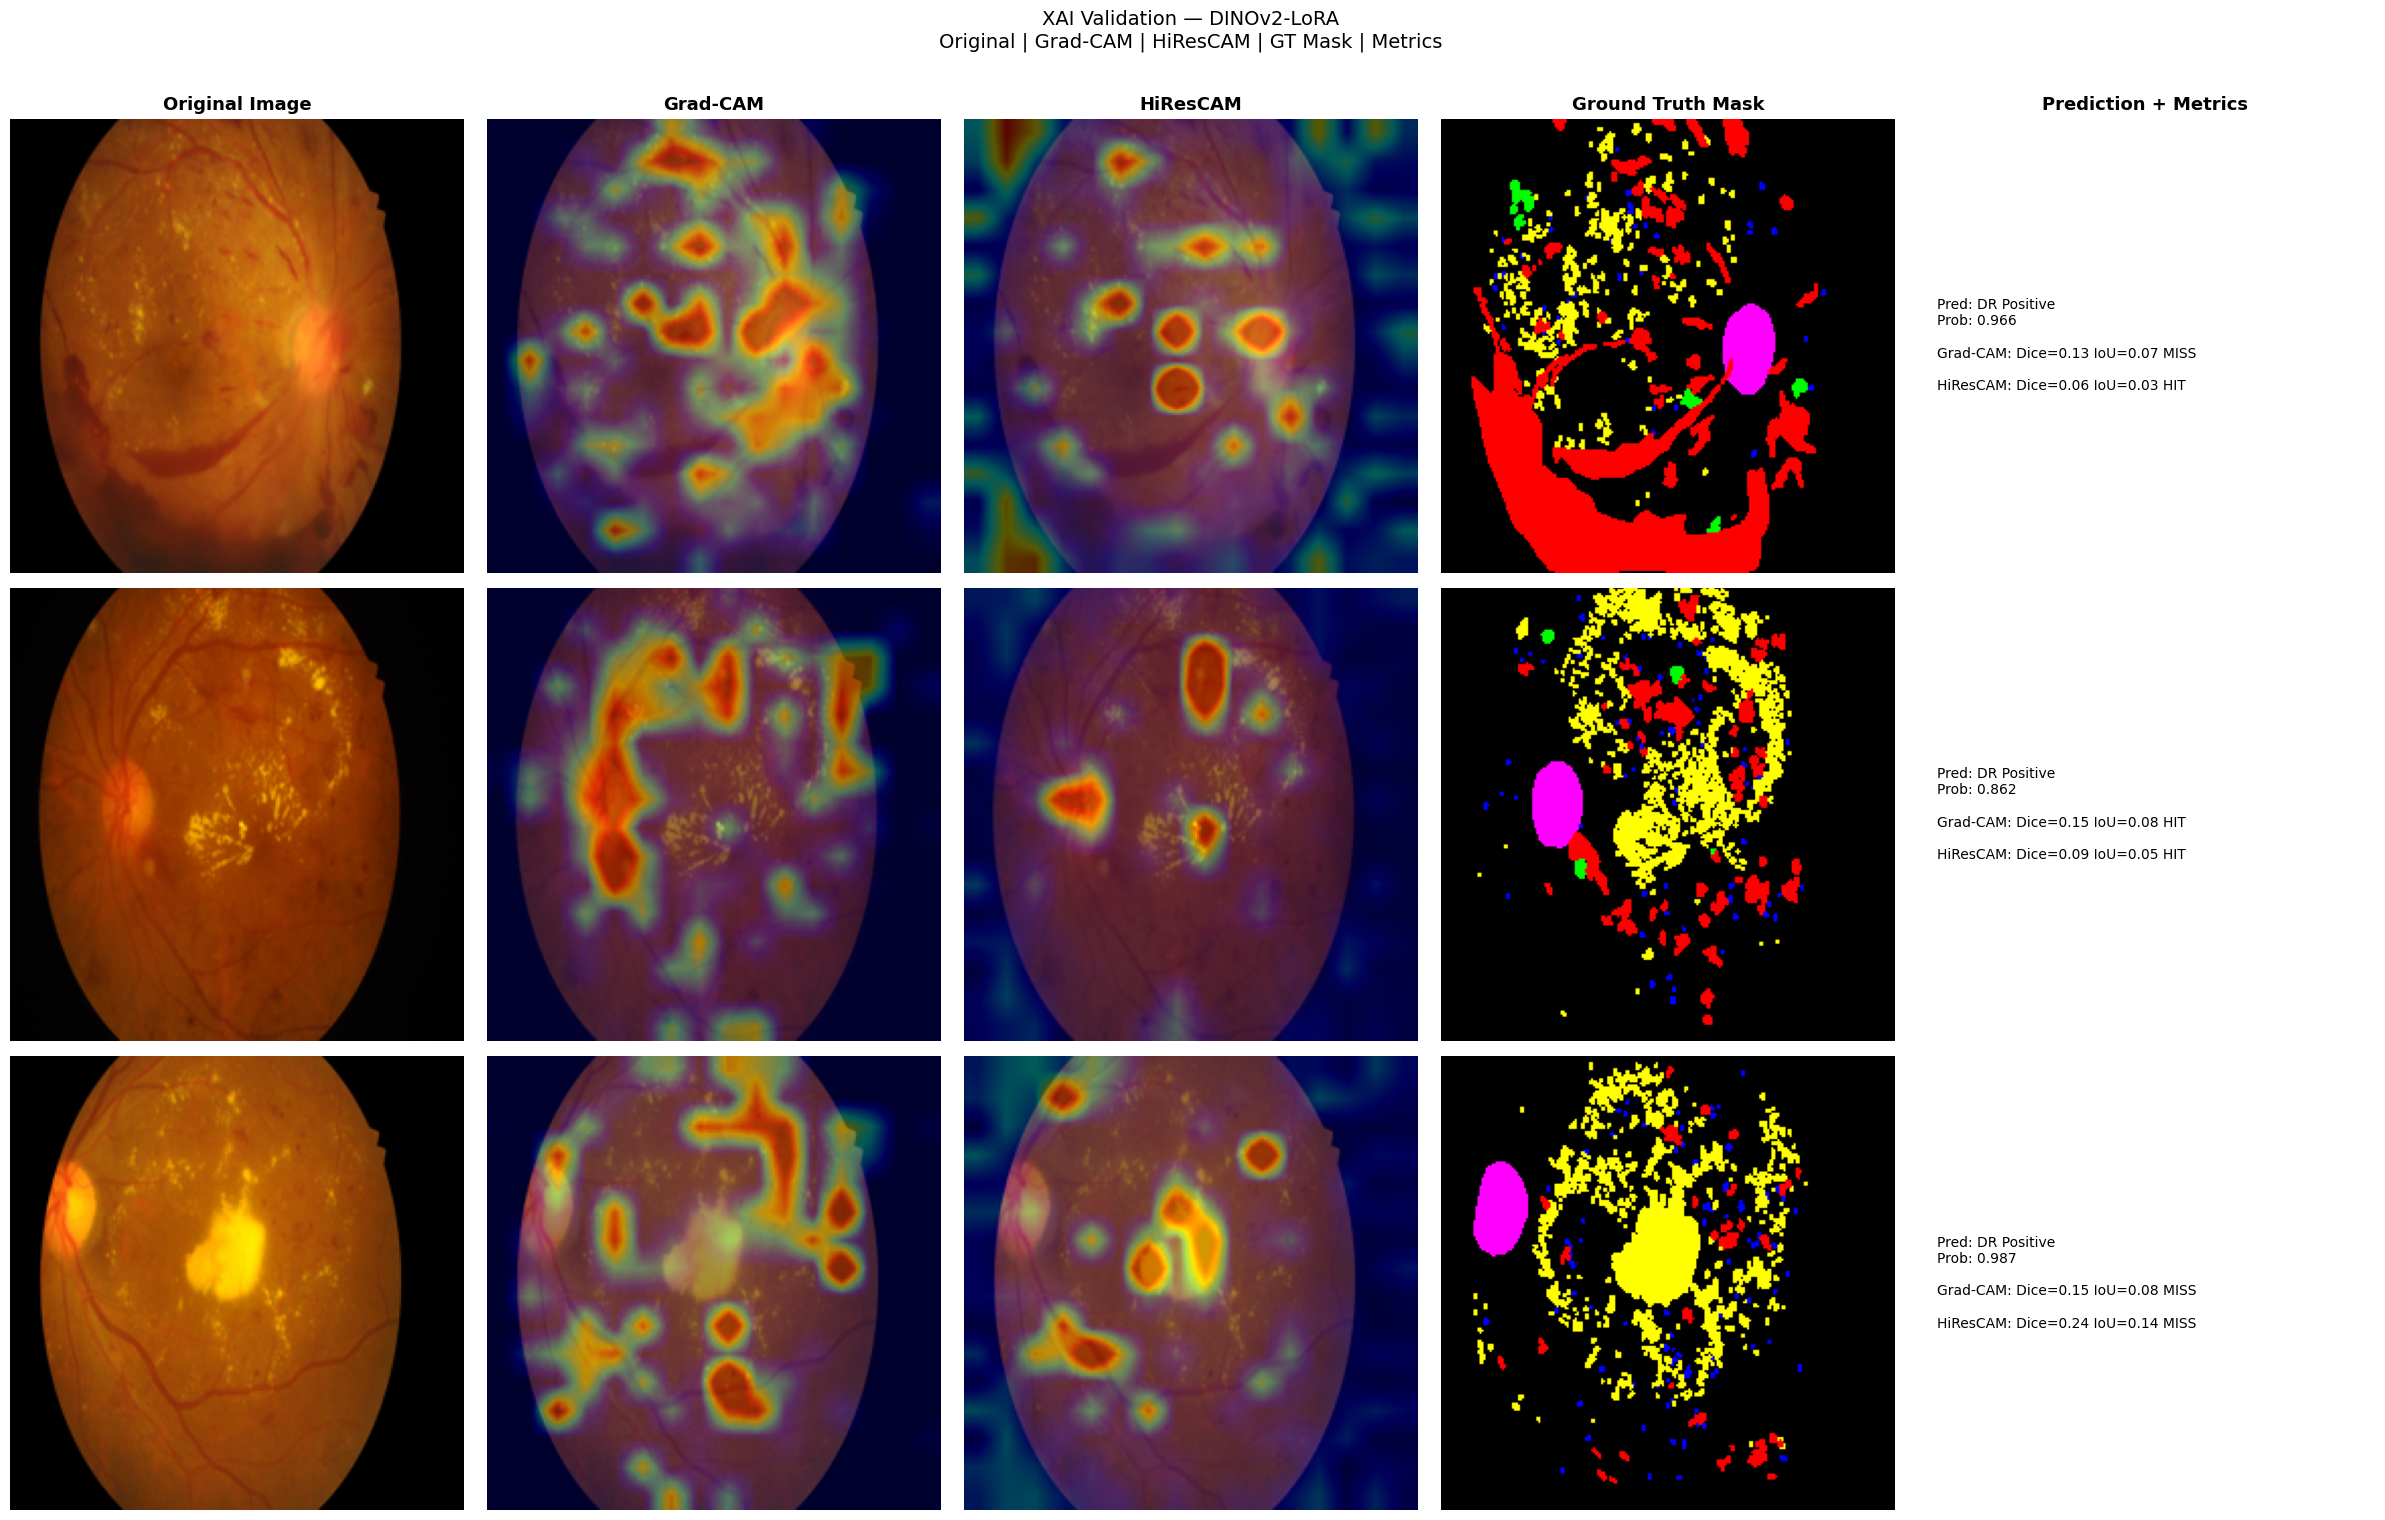


Grid saved: /content/drive/MyDrive/Retinal_project/plots_complete/xai_final_grid_lesiononly.png


In [ ]:
# =============================================================================
# BUILD GRID: Original | Grad-CAM | HiResCAM | GT Mask (composite) | Metrics
# =============================================================================
results_table = []
fig, axes = plt.subplots(len(selected_final), 5, figsize=(24, 5*len(selected_final)))
if len(selected_final) == 1: axes = axes.reshape(1,-1)

col_titles = ["Original Image", "Grad-CAM", "HiResCAM", "Ground Truth Mask", "Prediction + Metrics"]
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=13, fontweight="bold")

for i, s in enumerate(selected_final):
    print(f"\n=== Sample {i+1}: {s['id']} (grade={s['grade']}) ===")
    orig = Image.open(s["img_path"]).convert("RGB")
    inp  = eval_transform(orig).unsqueeze(0).to(device)

    prob, pred_label = s["prob"], s["pred"]

    cam_heat   = get_cam(gradcam_extractor, inp)
    hires_heat = get_cam(hirescam_extractor, inp)
    cam_ov     = overlay(orig, cam_heat)
    hires_ov   = overlay(orig, hires_heat)

    # --- FIX: metrics computed on LESION-ONLY mask (OD excluded) ---
    lesion_paths      = lesion_only_mask_paths(s["numeric_id"])
    gt_binary_lesion  = combined_mask_binary(lesion_paths)
    # --- visualization still shows the composite mask (OD included) ---
    gt_color = combined_mask_color(s["numeric_id"])

    dice_cam, iou_cam     = dice_iou(cam_heat, gt_binary_lesion)
    dice_hires, iou_hires = dice_iou(hires_heat, gt_binary_lesion)
    hit_cam   = pointing_game(cam_heat, gt_binary_lesion)
    hit_hires = pointing_game(hires_heat, gt_binary_lesion)

    results_table.append({
        "id": s["id"], "grade": s["grade"], "prob": prob, "pred": pred_label,
        "dice_gradcam": dice_cam, "iou_gradcam": iou_cam, "pg_gradcam": hit_cam,
        "dice_hirescam": dice_hires, "iou_hirescam": iou_hires, "pg_hirescam": hit_hires,
    })

    print(f"  Prediction: {pred_label} (prob={prob:.3f})")
    print(f"  Grad-CAM  -> Dice={dice_cam:.3f} IoU={iou_cam:.3f} PointingGame={'HIT' if hit_cam else 'MISS'}")
    print(f"  HiResCAM  -> Dice={dice_hires:.3f} IoU={iou_hires:.3f} PointingGame={'HIT' if hit_hires else 'MISS'}")

    axes[i,0].imshow(np.array(orig.resize((224,224))))
    axes[i,0].set_ylabel(f"Sample {i+1}\nGrade={s['grade']}", fontsize=10)
    axes[i,0].axis("off")
    axes[i,1].imshow(cam_ov); axes[i,1].axis("off")
    axes[i,2].imshow(hires_ov); axes[i,2].axis("off")
    axes[i,3].imshow(gt_color); axes[i,3].axis("off")
    axes[i,4].axis("off")
    info_text = (f"Pred: {pred_label}\nProb: {prob:.3f}\n\n"
                 f"Grad-CAM: Dice={dice_cam:.2f} IoU={iou_cam:.2f} {'HIT' if hit_cam else 'MISS'}\n\n"
                 f"HiResCAM: Dice={dice_hires:.2f} IoU={iou_hires:.2f} {'HIT' if hit_hires else 'MISS'}")
    axes[i,4].text(0.05, 0.5, info_text, fontsize=10, va="center")

plt.suptitle(f"XAI Validation — {BEST_NAME}\nOriginal | Grad-CAM | HiResCAM | GT Mask | Metrics",
             fontsize=14, y=1.01)
plt.tight_layout()
grid_path = os.path.join(PLOT_DIR, "xai_final_grid_lesiononly.png")
plt.savefig(grid_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nGrid saved: {grid_path}")


In [ ]:
# =============================================================================
# CAPTION
# =============================================================================
caption = (
    f"Figure: XAI validation for {BEST_NAME} on three high-confidence "
    "(prediction probability > 0.8), correctly classified DR-positive IDRiD samples, "
    "selected by largest annotated lesion area. Columns (left to right): original fundus "
    "image; Grad-CAM saliency map; HiResCAM saliency map; composite ground-truth "
    "annotation mask; predicted probability and quantitative overlap metrics. "
    "Ground-truth mask color legend — blue: Microaneurysms (MA), red: Haemorrhages (HE), "
    "yellow: Hard Exudates (EX), green: Soft Exudates (SE), magenta: Optic Disc (OD, shown "
    "for anatomical reference only). Dice, IoU, and Pointing Game metrics are computed "
    "against the clinically meaningful lesion set (MA + HE + EX + SE); the Optic Disc is a "
    "normal anatomical structure, not a pathological lesion, and is excluded from the "
    "quantitative overlap metrics. Since the network was trained for image-level binary "
    "classification rather than pixel-wise lesion segmentation, moderate Dice/IoU overlap "
    "is expected and is consistent with prior classification-based XAI validation studies."
)
print("\n" + "="*90)
print("FIGURE CAPTION:")
print(caption)
with open(os.path.join(SAVE_DIR, "xai_figure_caption.txt"), "w") as f:
    f.write(caption)



FIGURE CAPTION:
Figure: XAI validation for DINOv2-LoRA on three high-confidence (prediction probability > 0.8), correctly classified DR-positive IDRiD samples, selected by largest annotated lesion area. Columns (left to right): original fundus image; Grad-CAM saliency map; HiResCAM saliency map; composite ground-truth annotation mask; predicted probability and quantitative overlap metrics. Ground-truth mask color legend — blue: Microaneurysms (MA), red: Haemorrhages (HE), yellow: Hard Exudates (EX), green: Soft Exudates (SE), magenta: Optic Disc (OD, shown for anatomical reference only). Dice, IoU, and Pointing Game metrics are computed against the clinically meaningful lesion set (MA + HE + EX + SE); the Optic Disc is a normal anatomical structure, not a pathological lesion, and is excluded from the quantitative overlap metrics. Since the network was trained for image-level binary classification rather than pixel-wise lesion segmentation, moderate Dice/IoU overlap is expected and is 

In [ ]:
# =============================================================================
# METRICS TABLE
# =============================================================================
df_results = pd.DataFrame(results_table)
print("\n" + "="*90)
print("PER-SAMPLE METRICS (lesion-only ground truth):")
print(df_results.to_string(index=False))
df_results.to_csv(os.path.join(SAVE_DIR, "xai_metrics_lesiononly.csv"), index=False)
print(f"\nMetrics saved: {os.path.join(SAVE_DIR, 'xai_metrics_lesiononly.csv')}")

print("\nAVERAGE METRICS ACROSS SAMPLES:")
print(f"  Grad-CAM  — Mean Dice: {df_results['dice_gradcam'].mean():.3f} | "
      f"Mean IoU: {df_results['iou_gradcam'].mean():.3f} | "
      f"Pointing Game Hit Rate: {df_results['pg_gradcam'].mean()*100:.0f}%")
print(f"  HiResCAM  — Mean Dice: {df_results['dice_hirescam'].mean():.3f} | "
      f"Mean IoU: {df_results['iou_hirescam'].mean():.3f} | "
      f"Pointing Game Hit Rate: {df_results['pg_hirescam'].mean()*100:.0f}%")

del model
gc.collect(); torch.cuda.empty_cache()
print("\nDONE — XAI validation complete (lesion-only metrics).")



PER-SAMPLE METRICS (lesion-only ground truth):
      id  grade     prob        pred  dice_gradcam  iou_gradcam  pg_gradcam  dice_hirescam  iou_hirescam  pg_hirescam
IDRiD_17      4 0.966353 DR Positive      0.130068     0.069558       False       0.058411      0.030084         True
IDRiD_25      3 0.862066 DR Positive      0.152458     0.082519        True       0.090871      0.047598         True
IDRiD_10      4 0.987194 DR Positive      0.147948     0.079883       False       0.239099      0.135782        False

Metrics saved: /content/drive/MyDrive/Retinal_project/checkpoints/xai_metrics_lesiononly.csv

AVERAGE METRICS ACROSS SAMPLES:
  Grad-CAM  — Mean Dice: 0.143 | Mean IoU: 0.077 | Pointing Game Hit Rate: 33%
  HiResCAM  — Mean Dice: 0.129 | Mean IoU: 0.071 | Pointing Game Hit Rate: 67%

DONE — XAI validation complete (lesion-only metrics).
